## Importaciones necesarias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Inicio del código:
Análisis sencillo de datos

In [3]:
df = pd.read_csv('Recursos/camara.csv')

In [4]:
print(df.head())

        Fecha Producto  Cantidad  Precio_unitario
0  2025-11-18       Té         3             3560
1  2025-11-21    Queso         1             2746
2  2025-11-28      Pan         9             1160
3  2025-11-23    Queso         4             2842
4  2025-12-01    Arepa         8             1902


In [5]:
df['total_compra'] = df['Cantidad'] * df['Precio_unitario']

In [6]:
df.head()

,Fecha,Producto,Cantidad,Precio_unitario,total_compra
0,2025-11-18,Té,3,3560,10680
1,2025-11-21,Queso,1,2746,2746
2,2025-11-28,Pan,9,1160,10440
3,2025-11-23,Queso,4,2842,11368
4,2025-12-01,Arepa,8,1902,15216


## Verificacion Tipo de Datos

In [7]:
print(df.dtypes)

Fecha              object
Producto           object
Cantidad            int64
Precio_unitario     int64
total_compra        int64
dtype: object


## Limpieza de Tipado de Datos

In [8]:
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Producto'] = df['Producto'].astype(str)
df['Precio_unitario'] = df['Precio_unitario'].astype(float)
df['total_compra'] = df['total_compra'].astype(float)

### Día con menos ventas

In [9]:
ventas_dia = df.groupby('Fecha')['total_compra'].sum()
dia_menos_venta = ventas_dia.idxmin()
print(f"El dia con menos ventas fue: {dia_menos_venta}")

El dia con menos ventas fue: 2025-11-10 00:00:00


### Día con mas ventas

In [11]:
dia_mas_ventas = ventas_dia.idxmax()
print(f"El dia con mas ventas fue: {dia_mas_ventas}")

El dia con mas ventas fue: 2025-11-12 00:00:00


### Calcular producto menos vendido

In [29]:
cantidad_producto = df.groupby('Producto')['Cantidad'].sum()
producto_menos_vendido = cantidad_producto.idxmin()
print(f"El producto menos vendido es: {producto_menos_vendido}")

El producto menos vendido es: Yogurt


### Calcular producto mas vendido

In [30]:
producto_mas_vendido = cantidad_producto.idxmax()
print(f"El producto mas vendido es: {producto_mas_vendido}")

El producto mas vendido es: Queso


### Calcular total de ventas general

In [31]:
total_ventas = df['total_compra'].sum()
print(f"El total de ventas es de: {total_ventas}")

El total de ventas es de: 32166842.0


### Calcular total de ventas por producto

In [32]:
venta_producto = df.groupby('Producto')['total_compra'].sum()
print(venta_producto)

Producto
Arepa          3034366.0
Café           2951672.0
Chocolate      3063969.0
Galletas       3172253.0
Leche          3460485.0
Mantequilla    3578693.0
Pan            3407760.0
Queso          3443559.0
Té             3121239.0
Yogurt         2932846.0
Name: total_compra, dtype: float64


## Grafica hechas con la libreria matplotlib

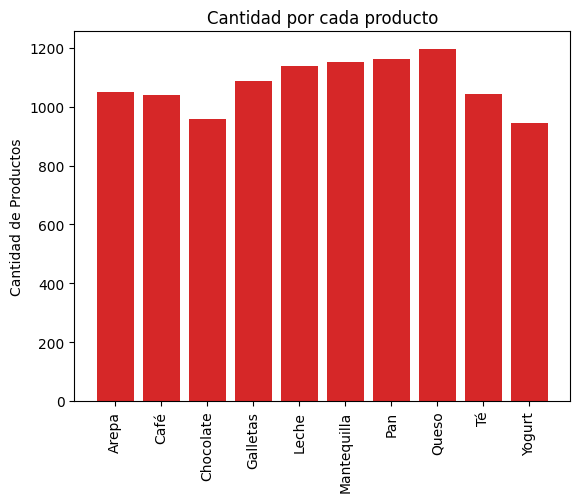

In [42]:
fig, ax = plt.subplots()

counts = df.groupby('Producto')['Cantidad'].sum()
products = counts.index

ax.bar(products, counts, color='tab:red')
ax.set_ylabel('Cantidad de Productos')
ax.set_title('Cantidad por cada producto')

plt.xticks(rotation=90)
plt.show()


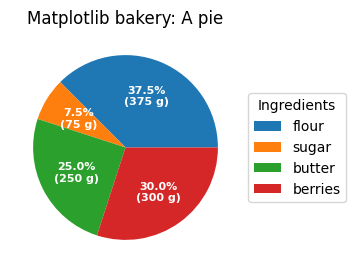

In [51]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))

recipe = ["375 g flour",
          "75 g sugar",
          "250 g butter",
          "300 g berries"]

data = [float(x.split()[0]) for x in recipe]
ingredients = [x.split()[-1] for x in recipe]


def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute:d} g)"


wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct, data),
                                  textprops=dict(color="w"))

ax.legend(wedges, ingredients,
          title="Ingredients",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("Matplotlib bakery: A pie")

plt.show()